# Digital Finance, Forecasting & Analytics Platform
## Module 3 - IFRS Reporting Automation & Anomaly Detection (Python + SQLAlchemy + Pandas)
### 3.1 — Anomaly Detection: Actuals

**Scope:** All 11 fact tables + 3 monthly IFRS views (actuals only, `scenariokey = 1`)  
**Goal:** Detect statistical anomalies and validate that views are correctly derived from fact tables  
**Layers:**
- Layer 1 — Data Quality Gate (schema, nulls, duplicates, cross-validation facts→views, BS reconciliation)
- Layer 2 — Z-Score (monthly KPIs, threshold |z| > 2.5)
- Layer 3 — STL Decomposition (seasonal-trend residuals)
- Layer 4 — Isolation Forest (multivariate, ~20 features)
- Ensemble Score: Z(30%) + STL(35%) + IF(35%)

## 0. Setup — Imports & Logging

In [1]:
import os
import logging
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError

from scipy.stats import zscore
from statsmodels.tsa.seasonal import STL
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S"
)
logger = logging.getLogger(__name__)

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_colwidth", 60)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)

# ── Parameters ──────────────────────────────────────────────────────────────
SCHEMA       = "finance_ifrs_dw"
SCENARIO_KEY = 1          # actuals only
THRESHOLD_Z  = 2.5        # z-score anomaly threshold
STL_PERIOD   = 12         # monthly seasonality
IF_N_EST     = 200        # Isolation Forest estimators
IF_CONTAM    = 0.05       # expected outlier fraction
W_Z, W_STL, W_IF = 0.30, 0.35, 0.35   # ensemble weights

print("Libraries loaded.")
print(f"Ensemble weights → Z-Score: {W_Z:.0%} | STL: {W_STL:.0%} | Isolation Forest: {W_IF:.0%}")

Libraries loaded.
Ensemble weights → Z-Score: 30% | STL: 35% | Isolation Forest: 35%


## Ensemble Anomaly Scoring (Logic & Weights)

An **ensemble model** combines multiple anomaly detection methods into a single, more robust score.

In this project, three complementary techniques are used:
- **Z-Score (30%)** → detects statistical extremes
- **STL (35%)** → detects deviations from trend and seasonality
- **Isolation Forest (35%)** → detects complex multivariate anomalies

The final score is a **weighted average**:
`Ensemble Score = 0.30 × Z + 0.35 × STL + 0.35 × IF`

### Why weighting matters
- STL and Isolation Forest have higher weight because they better capture real financial behavior
- Z-Score has lower weight as it is simpler and more sensitive to noise

### Business relevance
Financial anomalies can come from:
- structural breaks (crisis, recovery)
- seasonality shifts
- KPI interactions (e.g., revenue vs margin)

The ensemble approach reduces false positives and provides a more reliable signal for financial monitoring and FP&A analysis.

## 1. Database Connection

In [2]:
load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME")

if not all([DB_USER, DB_PASS, DB_NAME]):
    raise EnvironmentError("Missing DB credentials in .env file (DB_USER, DB_PASS, DB_NAME required).")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_pre_ping=True
)

with engine.connect() as conn:
    result = conn.execute(text("SELECT current_database(), current_schema()"))
    db, schema = result.fetchone()
    print(f"Connected to database: {db} | default schema: {schema}")

logger.info("DB connection established.")

11:17:41 [INFO] DB connection established.


Connected to database: finance_ifrs_dw | default schema: public


## 2. Extract: Monthly IFRS Views (Actuals)

In [3]:
view_queries = {
    "pl_monthly": f"SELECT * FROM {SCHEMA}.vw_pl_monthly ORDER BY datekey",
    "cf_monthly": f"SELECT * FROM {SCHEMA}.vw_cf_monthly ORDER BY datekey",
    "bs_monthly": f"SELECT * FROM {SCHEMA}.vw_bs_monthly ORDER BY datekey",
}

dfs_views = {}
for name, query in view_queries.items():
    try:
        df = pd.read_sql(query, engine).round(2)

        # datekey is a YYYYMM key, not a native datetime
        if "datekey" in df.columns:
            df["datekey"] = pd.to_numeric(df["datekey"], errors="coerce").astype("Int64")
            df["date"] = pd.to_datetime(df["datekey"].astype(str), format="%Y%m", errors="coerce")

        dfs_views[name] = df

        print(
            f"  {name:12s}: {df.shape[0]:4d} rows x {df.shape[1]:2d} cols | "
            f"range: {df['date'].min().strftime('%Y-%m') if 'date' in df.columns and df['date'].notna().any() else 'n/a'} -> "
            f"{df['date'].max().strftime('%Y-%m') if 'date' in df.columns and df['date'].notna().any() else 'n/a'}"
        )

    except SQLAlchemyError as e:
        logger.error(f"Failed to load {name}: {e}")
        dfs_views[name] = pd.DataFrame()

df_plm = dfs_views["pl_monthly"]
df_cfm = dfs_views["cf_monthly"]
df_bsm = dfs_views["bs_monthly"]

print("\nP&L Monthly columns  :", list(df_plm.columns))
print("Cash Flow Monthly cols:", list(df_cfm.columns))
print("Balance Sheet Monthly :", list(df_bsm.columns))

  pl_monthly  :  180 rows x 19 cols | range: 2010-01 -> 2024-12
  cf_monthly  :  180 rows x 13 cols | range: 2010-01 -> 2024-12
  bs_monthly  :  180 rows x 24 cols | range: 2010-01 -> 2024-12

P&L Monthly columns  : ['datekey', 'year', 'month', 'revenue', 'cogs', 'COGS (%)', 'gross_profit', 'Gross (%)', 'opex', 'Opex (%)', 'ebitda', 'EBITDA (%)', 'depreciation', 'financial_results', 'ebt', 'totaltaxes', 'net_income', 'Net Margin (%)', 'date']
Cash Flow Monthly cols: ['datekey', 'year', 'month', 'delta_ar', 'delta_inventory', 'delta_ap', 'delta_debt', 'revolving_credit', 'cfo', 'cfi', 'cff', 'cash_end', 'date']
Balance Sheet Monthly : ['datekey', 'year', 'month', 'cash', 'accountsreceivable', 'inventory', 'currentassets', 'ppe', 'intangibleassets', 'deferredtaxes', 'othernoncurrentassets', 'noncurrentassets', 'totalassets', 'accountspayable', 'revolvingcredit', 'currentliabilities', 'noncurrentliabilities', 'totalliabilities', 'capital', 'retainedearnings', 'dividends', 'totalequity', '

## 3. Extract: All 11 Fact Tables (scenariokey = 1)

In [4]:
FACT_TABLES = [
    "fact_sales", "fact_cogs", "fact_opex", "fact_depreciation",
    "fact_assets", "fact_debt", "fact_equity", "fact_taxes",
    "fact_workingcapital", "fact_cashflow", "fact_price_volume"
]

def extract_fact(fact_name: str) -> pd.DataFrame:
    """Extract fact table joined with dim_date for MonthYear label, scenariokey=1 only."""
    query = f"""
        SELECT d.MonthYear, f.*
        FROM {SCHEMA}.{fact_name} f
        JOIN {SCHEMA}.dim_date d ON f.DateKey = d.DateKey
        WHERE f.scenariokey = {SCENARIO_KEY}
        ORDER BY d.MonthYear
    """
    df = pd.read_sql(query, engine).round(2)
    # Normalize datekey to datetime
    for col in ["datekey", "DateKey"]:
        if col in df.columns:
            df.rename(columns={col: "datekey"}, inplace=True)
            df["datekey"] = pd.to_numeric(df["datekey"], errors="coerce").astype("Int64")
            df["date"] = pd.to_datetime(df["datekey"].astype(str), format="%Y%m", errors="coerce")
            break
    return df

facts = {}
print("Extracting fact tables (scenariokey=1)...")
for name in FACT_TABLES:
    try:
        facts[name] = extract_fact(name)
        print(f"  {name:22s}: {facts[name].shape[0]:5d} rows × {facts[name].shape[1]:2d} cols")
    except SQLAlchemyError as e:
        logger.error(f"Failed to load {name}: {e}")
        facts[name] = pd.DataFrame()

print(f"\nAll {len([f for f in facts.values() if not f.empty])} fact tables extracted.")

Extracting fact tables (scenariokey=1)...
  fact_sales            :  1620 rows ×  9 cols
  fact_cogs             :   540 rows ×  8 cols
  fact_opex             :  1260 rows ×  8 cols
  fact_depreciation     :   180 rows ×  7 cols
  fact_assets           :  1080 rows ×  7 cols
  fact_debt             :   720 rows ×  7 cols
  fact_equity           :   540 rows ×  7 cols
  fact_taxes            :   360 rows ×  7 cols
  fact_workingcapital   :   540 rows ×  7 cols
  fact_cashflow         :  1620 rows ×  7 cols
  fact_price_volume     :  1620 rows ×  8 cols

All 11 fact tables extracted.


## 4. Layer 1A — Data Quality Gate (Schema, Nulls, Duplicates)

In [5]:
quality_results = []

def _datekey_to_month_start(series: pd.Series) -> pd.Series:
    """Convert YYYYMM integer-like key to month-start datetime."""
    s = pd.to_numeric(series, errors="coerce")
    return pd.to_datetime(s.astype("Int64").astype(str), format="%Y%m", errors="coerce")

def check_quality(df: pd.DataFrame, source_name: str) -> dict:
    """Run basic quality checks: shape, null%, duplicates, date continuity."""
    result = {"source": source_name, "rows": len(df), "cols": len(df.columns)}

    if df.empty:
        result.update({"null_pct": None, "dup_rows": None, "date_gaps": None, "status": "EMPTY"})
        return result

    # Null percentage across numeric columns
    num_cols = df.select_dtypes(include=[np.number]).columns
    null_pct = df[num_cols].isnull().mean().mean() * 100 if len(num_cols) else 0.0
    result["null_pct"] = round(null_pct, 2)

    # Duplicate rows
    dup_rows = df.duplicated().sum()
    result["dup_rows"] = int(dup_rows)

    # Date gaps
    date_gaps = 0

    # Prefer real date column when available
    if "date" in df.columns:
        date_series = pd.to_datetime(df["date"], errors="coerce").dropna().sort_values().drop_duplicates()
        if len(date_series) > 1:
            expected_months = pd.date_range(date_series.iloc[0], date_series.iloc[-1], freq="MS")
            date_gaps = len(expected_months.difference(pd.DatetimeIndex(date_series)))

    # Otherwise derive from YYYYMM datekey
    elif "datekey" in df.columns:
        date_series = _datekey_to_month_start(df["datekey"]).dropna().sort_values().drop_duplicates()
        if len(date_series) > 1:
            expected_months = pd.date_range(date_series.iloc[0], date_series.iloc[-1], freq="MS")
            date_gaps = len(expected_months.difference(pd.DatetimeIndex(date_series)))

    result["date_gaps"] = int(date_gaps)

    # Overall status
    issues = (null_pct > 5) + (dup_rows > 0) + (date_gaps > 0)
    result["status"] = "PASS" if issues == 0 else ("WARN" if issues == 1 else "FAIL")
    return result

# Check all views
for name, df in dfs_views.items():
    quality_results.append(check_quality(df, f"view:{name}"))

# Check all facts
for name, df in facts.items():
    quality_results.append(check_quality(df, f"fact:{name}"))

df_quality = pd.DataFrame(quality_results)
print("=" * 70)
print("LAYER 1A — DATA QUALITY GATE")
print("=" * 70)
print(df_quality.to_string(index=False))

pass_count = (df_quality["status"] == "PASS").sum()
fail_count = (df_quality["status"] == "FAIL").sum()
warn_count = (df_quality["status"] == "WARN").sum()
print(f"\nSummary: {pass_count} PASS | {warn_count} WARN | {fail_count} FAIL (of {len(df_quality)} datasets)")

LAYER 1A — DATA QUALITY GATE
                  source  rows  cols  null_pct  dup_rows  date_gaps status
         view:pl_monthly   180    19      0.00         0          0   PASS
         view:cf_monthly   180    13      0.00         0          0   PASS
         view:bs_monthly   180    24      0.00         0          0   PASS
         fact:fact_sales  1620     9      0.00         0          0   PASS
          fact:fact_cogs   540     8      0.00         0          0   PASS
          fact:fact_opex  1260     8      0.00         0          0   PASS
  fact:fact_depreciation   180     7      0.00         0          0   PASS
        fact:fact_assets  1080     7      0.00         0          0   PASS
          fact:fact_debt   720     7      0.00         0          0   PASS
        fact:fact_equity   540     7      0.00         0          0   PASS
         fact:fact_taxes   360     7      0.00         0          0   PASS
fact:fact_workingcapital   540     7      0.00         0          0   P

## 5. Layer 1B — Cross-Validation: Facts → Views

In [6]:
cv_results = []


def cross_validate(fact_agg, view_series, label):
    """
    PASS if max absolute diff between fact aggregate and view column < 0.05.
    Both series must be indexed by datekey.
    """
    fact_df = fact_agg.reset_index().rename(
        columns={fact_agg.name: "fact", "index": "datekey"}
    )
    view_df = view_series.reset_index().rename(
        columns={view_series.name: "view", "index": "datekey"}
    )

    if "datekey" not in fact_df.columns:
        fact_df.columns = ["datekey", "fact"]

    if "datekey" not in view_df.columns:
        view_df.columns = ["datekey", "view"]

    merged = pd.merge(fact_df, view_df, on="datekey", how="inner")

    if merged.empty:
        return {
            "check": label,
            "rows_matched": 0,
            "max_diff": None,
            "max_diff_pct": None,
            "status": "NO_MATCH",
        }

    diff_abs = (merged["fact"] - merged["view"]).abs()
    max_diff = diff_abs.max()
    max_diff_pct = (diff_abs / merged["view"].replace(0, np.nan) * 100).max()

    return {
        "check": label,
        "rows_matched": len(merged),
        "max_diff": round(max_diff, 4),
        "max_diff_pct": round(max_diff_pct, 4) if pd.notna(max_diff_pct) else None,
        "status": "PASS" if max_diff < 0.05 else "FAIL",
    }


def fact_sum(fact_name, amount_col="amount"):
    """
    Sum ALL numeric amounts for a single-account fact (sales, cogs, opex, dep).
    """
    df = facts.get(fact_name, pd.DataFrame())

    if df.empty:
        return pd.Series(dtype=float, name=amount_col)

    num_cols = [
        c
        for c in df.select_dtypes(include=[np.number]).columns
        if c not in ["scenariokey", "productkey", "customerkey", "channelkey"]
    ]

    if amount_col not in df.columns:
        amount_col = num_cols[0] if num_cols else None

    if amount_col is None:
        return pd.Series(dtype=float, name=amount_col)

    return df.groupby("datekey")[amount_col].sum().rename(amount_col)


def fact_sum_account(fact_name, account_name, amount_col="amount"):
    """
    Filter to a single AccountName (case-insensitive) then sum by datekey.
    Use for multi-account facts: fact_cashflow, fact_equity, fact_assets, fact_workingcapital.
    """
    df = facts.get(fact_name, pd.DataFrame())

    if df.empty or "accountname" not in df.columns:
        return pd.Series(dtype=float, name=account_name)

    mask = df["accountname"].str.strip().str.lower() == account_name.lower()
    df_f = df[mask]

    if df_f.empty:
        avail = df["accountname"].str.strip().unique().tolist()[:8]
        logger.warning(
            f"{fact_name}: AccountName {repr(account_name)} not found. Available: {avail}"
        )
        return pd.Series(dtype=float, name=account_name)

    num_cols = [
        c
        for c in df_f.select_dtypes(include=[np.number]).columns
        if c not in [
            "scenariokey",
            "productkey",
            "customerkey",
            "channelkey",
            "datekey",
        ]
    ]

    if amount_col not in df_f.columns:
        amount_col = num_cols[0] if num_cols else None

    if amount_col is None:
        return pd.Series(dtype=float, name=account_name)

    return df_f.groupby("datekey")[amount_col].sum().rename(account_name)


# =============================================================================
# P&L: single-account facts -- full sum matches view column directly
# =============================================================================
plm_cols = {c.lower(): c for c in df_plm.columns}

if "revenue" in plm_cols:
    cv_results.append(
        cross_validate(
            fact_sum("fact_sales"),
            df_plm.set_index("datekey")[plm_cols["revenue"]].rename("revenue"),
            "Revenue: fact_sales -> vw_pl_monthly",
        )
    )

for cand in ["cogs"]:
    if cand in plm_cols:
        cv_results.append(
            cross_validate(
                fact_sum("fact_cogs"),
                df_plm.set_index("datekey")[plm_cols[cand]].rename(cand),
                "COGS: fact_cogs -> vw_pl_monthly",
            )
        )

for cand in ["opex"]:
    if cand in plm_cols:
        cv_results.append(
            cross_validate(
                fact_sum("fact_opex"),
                df_plm.set_index("datekey")[plm_cols[cand]].rename(cand),
                "OpEx: fact_opex -> vw_pl_monthly",
            )
        )

for cand in ["depreciation"]:
    if cand in plm_cols:
        cv_results.append(
            cross_validate(
                fact_sum("fact_depreciation"),
                df_plm.set_index("datekey")[plm_cols[cand]].rename(cand),
                "Depreciation: fact_depreciation -> vw_pl_monthly",
            )
        )

# =============================================================================
# Cash Flow: fact_cashflow has MULTIPLE accounts (CFO, CFI, CFF, CashEnd, DeltaAR...)
# Each account maps to its OWN column in vw_cf_monthly.
# Never use fact_sum() here -- it would sum all accounts and match nothing.
# =============================================================================
cfm_cols = {c.lower(): c for c in df_cfm.columns}

cf_account_map = {
    "CFO": ["cfo"],
    "CFI": ["cfi"],
    "CFF": ["cff"],
    "CashEnd": ["cash_end", "cashend"],
    "DeltaAR": ["delta_ar", "deltaar"],
    "DeltaInventory": ["delta_inventory", "deltainventory"],
    "DeltaAP": ["delta_ap", "deltaap"],
    "RevolvingCredit": ["revolving_credit", "revolvingcredit"],
    "DeltaDebt": ["delta_debt", "deltadebt"],
}

for acct, candidates in cf_account_map.items():
    matched = next((cfm_cols[c] for c in candidates if c in cfm_cols), None)

    if matched:
        cv_results.append(
            cross_validate(
                fact_sum_account("fact_cashflow", acct),
                df_cfm.set_index("datekey")[matched].rename(acct),
                f"CF.{acct}: fact_cashflow -> vw_cf_monthly",
            )
        )

# =============================================================================
# Balance Sheet:
# fact_assets -> NonCurrentAssets = PPE + IntangibleAssets + DeferredTaxes + OtherNonCurrentAssets
# do NOT use SUM(fact_assets), because accounts like Capex and TaxBasis may exist
# in fact_assets but are not part of vw_bs_monthly.NonCurrentAssets.
# fact_cashflow -> Cash (filter AccountName = CashEnd)
# fact_wc -> AR, Inventory, AP
# fact_debt -> NonCurrentLiabilities
# fact_equity -> TotalEquity = Capital + RetainedEarnings
# (Dividends tracked separately, NOT part of TotalEquity in the view)
# =============================================================================
bsm_cols = {c.lower(): c for c in df_bsm.columns}

for cand in ["noncurrentassets", "non_current_assets"]:
    if cand in bsm_cols:
        _accts = ["PPE", "IntangibleAssets", "DeferredTaxes", "OtherNonCurrentAssets"]
        _parts = [s for s in (fact_sum_account("fact_assets", a) for a in _accts) if not s.empty]
        if _parts:
            _nca = _parts[0]
            for _s in _parts[1:]: _nca = _nca.add(_s, fill_value=0)
            cv_results.append(cross_validate(
                _nca.rename(cand),
                df_bsm.set_index("datekey")[bsm_cols[cand]].rename(cand),
                "NonCurrentAssets: fact_assets -> vw_bs_monthly"))
        break

if "ppe" in bsm_cols:
    cv_results.append(
        cross_validate(
            fact_sum_account("fact_assets", "PPE"),
            df_bsm.set_index("datekey")[bsm_cols["ppe"]].rename("ppe"),
            "PPE: fact_assets[PPE] -> vw_bs_monthly",
        )
    )

if "cash" in bsm_cols:
    cv_results.append(
        cross_validate(
            fact_sum_account("fact_cashflow", "CashEnd"),
            df_bsm.set_index("datekey")[bsm_cols["cash"]].rename("cash"),
            "Cash: fact_cashflow[CashEnd] -> vw_bs_monthly",
        )
    )

for cand in ["accountsreceivable", "accounts_receivable"]:
    if cand in bsm_cols:
        cv_results.append(
            cross_validate(
                fact_sum_account("fact_workingcapital", "AccountsReceivable"),
                df_bsm.set_index("datekey")[bsm_cols[cand]].rename(cand),
                "AR: fact_workingcapital[AR] -> vw_bs_monthly",
            )
        )
        break

if "inventory" in bsm_cols:
    cv_results.append(
        cross_validate(
            fact_sum_account("fact_workingcapital", "Inventory"),
            df_bsm.set_index("datekey")[bsm_cols["inventory"]].rename("inventory"),
            "Inventory: fact_workingcapital[Inv] -> vw_bs_monthly",
        )
    )

for cand in ["accountspayable", "accounts_payable"]:
    if cand in bsm_cols:
        cv_results.append(
            cross_validate(
                fact_sum_account("fact_workingcapital", "AccountsPayable"),
                df_bsm.set_index("datekey")[bsm_cols[cand]].rename(cand),
                "AP: fact_workingcapital[AP] -> vw_bs_monthly",
            )
        )
        break

for cand in ["noncurrentliabilities", "non_current_liabilities"]:
    if cand in bsm_cols:
        cv_results.append(
            cross_validate(
                fact_sum_account("fact_debt", "NonCurrentLiabilities"),
                df_bsm.set_index("datekey")[bsm_cols[cand]].rename(cand),
                "NonCurrentLiab: fact_debt -> vw_bs_monthly",
            )
        )
        break

for cand in ["totalequity", "total_equity"]:
    if cand in bsm_cols:
        cap_agg = fact_sum_account("fact_equity", "Capital")
        re_agg = fact_sum_account("fact_equity", "RetainedEarnings")

        if not cap_agg.empty and not re_agg.empty:
            equity_agg = cap_agg.add(re_agg, fill_value=0).rename("cap_re")
        else:
            equity_agg = (cap_agg if not cap_agg.empty else re_agg).rename("cap_re")

        view_eq = df_bsm.set_index("datekey")[bsm_cols[cand]].rename("cap_re")

        cv_results.append(
            cross_validate(
                equity_agg,
                view_eq,
                "TotalEquity: fact_equity[Cap+RE] -> vw_bs_monthly",
            )
        )
        break

# =============================================================================
df_cv = pd.DataFrame(cv_results)

print("=" * 90)
print("LAYER 1B -- CROSS-VALIDATION: FACTS -> VIEWS")
print("=" * 90)
print(df_cv.to_string(index=False))

cv_pass = (df_cv["status"] == "PASS").sum()
cv_fail = (df_cv["status"] == "FAIL").sum()

print(f"\nResult: {cv_pass} PASS | {cv_fail} FAIL")

if cv_fail > 0:
    print("WARNING: View construction may contain errors -- investigate FAILed checks above.")

LAYER 1B -- CROSS-VALIDATION: FACTS -> VIEWS
                                               check  rows_matched  max_diff  max_diff_pct status
                Revenue: fact_sales -> vw_pl_monthly           180      0.00          0.00   PASS
                    COGS: fact_cogs -> vw_pl_monthly           180      0.00          0.00   PASS
                    OpEx: fact_opex -> vw_pl_monthly           180      0.00          0.00   PASS
    Depreciation: fact_depreciation -> vw_pl_monthly           180      0.00          0.00   PASS
              CF.CFO: fact_cashflow -> vw_cf_monthly           180      0.00          0.00   PASS
              CF.CFI: fact_cashflow -> vw_cf_monthly           180      0.00         -0.00   PASS
              CF.CFF: fact_cashflow -> vw_cf_monthly           180      0.00         -0.00   PASS
          CF.CashEnd: fact_cashflow -> vw_cf_monthly           180      0.00          0.00   PASS
          CF.DeltaAR: fact_cashflow -> vw_cf_monthly           180      0

## 6. Layer 1C — Balance Sheet Reconciliation (Assets = Liabilities + Equity)

In [7]:
# =============================================================================
# Layer 1C -- Balance Sheet Reconciliation
#
# The view vw_bs_monthly already computes an EquityCheck column:
#     EquityCheck = TotalAssets - TotalLiabilities - TotalEquity
#
# EXPECTED BEHAVIOUR:
#   Monthly: small non-zero differences are normal.
#     Reason: TotalEquity = Capital + RetainedEarnings (Dividends excluded by design).
#     Dividends are tracked separately for disclosure; they cause monthly timing differences
#     that net to zero when aggregated annually.
#   Annual: EquityCheck = 0.000 for all years (confirmed by Excel report).
#
# This cell checks both:
#   1. Use the pre-computed EquityCheck column (most reliable -- matches view intent)
#   2. Verify the annual aggregation nets to zero
# =============================================================================

bs_check = {"check": "BS Reconciliation (Assets = Liabilities + Equity)",
            "rows": len(df_bsm)}

bsm_lower = {c.lower(): c for c in df_bsm.columns}

# -- Option A: use pre-computed EquityCheck column from the view --
eq_check_col = next((bsm_lower[c] for c in ["equitycheck", "equity_check"] if c in bsm_lower), None)
col_assets  = next((bsm_lower[c] for c in ["totalassets",     "total_assets"]     if c in bsm_lower), None)
col_liab    = next((bsm_lower[c] for c in ["totalliabilities", "total_liabilities"] if c in bsm_lower), None)
col_equity  = next((bsm_lower[c] for c in ["totalequity",      "total_equity"]      if c in bsm_lower), None)

print(f"BS columns -> Assets: {col_assets} | Liabilities: {col_liab} | Equity: {col_equity} | EquityCheck: {eq_check_col}")

if eq_check_col:
    # Use the EquityCheck already computed by the view
    ec_series = df_bsm[eq_check_col].abs()
    max_diff_monthly  = ec_series.max()
    mean_diff_monthly = ec_series.mean()
    months_nonzero    = (ec_series > 0.01).sum()

    # Annual aggregation: sum EquityCheck per year
    df_bsm["year"] = df_bsm["date"].dt.year
    annual_check = df_bsm.groupby("year")[eq_check_col].sum().abs()
    max_diff_annual = annual_check.max()
    years_nonzero   = (annual_check > 0.01).sum()

    bs_check.update({
        "max_diff_monthly":  round(max_diff_monthly,  4),
        "mean_diff_monthly": round(mean_diff_monthly, 4),
        "months_nonzero":    int(months_nonzero),
        "max_diff_annual":   round(max_diff_annual,   4),
        "years_nonzero":     int(years_nonzero),
        "status": "PASS" if max_diff_annual < 0.01 else "FAIL"
    })

    print(f"\nMonthly EquityCheck | max: {max_diff_monthly:,.4f} | mean: {mean_diff_monthly:,.4f} | months != 0: {months_nonzero}")
    print(f"Annual  EquityCheck | max: {max_diff_annual:,.4f} | years  != 0: {years_nonzero}")
    print(f"Status: {bs_check['status']}")
    print()
    print("NOTE: Monthly differences are by design (Dividends excluded from TotalEquity).")
    print("      Annual = 0 confirms the model is structurally correct.")

    if months_nonzero > 0:
        worst = df_bsm.nlargest(5, eq_check_col)[["datekey", col_assets or "n/a",
                                                   col_liab  or "n/a",
                                                   col_equity or "n/a", eq_check_col]]
        print("\nTop 5 months with largest monthly imbalance (informational only):")
        print(worst.to_string(index=False))

elif col_assets and col_liab and col_equity:
    # Fallback: recompute manually
    df_bsm["bs_diff"] = (df_bsm[col_assets] - df_bsm[col_liab] - df_bsm[col_equity]).abs()
    max_diff    = df_bsm["bs_diff"].max()
    months_fail = (df_bsm["bs_diff"] > 0.01).sum()
    bs_ok       = max_diff < 0.01
    bs_check.update({
        "max_diff": round(max_diff, 4),
        "months_failing": int(months_fail),
        "status": "PASS" if bs_ok else "FAIL (check monthly vs annual -- see note above)"
    })
    print(f"BS Reconciliation -> max diff: {max_diff:,.4f} | months failing: {months_fail}")

else:
    bs_check.update({"status": "SKIP"})
    print("Skipping BS reconciliation -- could not identify required columns.")
    print(f"Available columns: {list(df_bsm.columns)}")

print("\n" + str(bs_check))


BS columns -> Assets: totalassets | Liabilities: totalliabilities | Equity: totalequity | EquityCheck: equitycheck

Monthly EquityCheck | max: 0.2200 | mean: 0.0110 | months != 0: 29
Annual  EquityCheck | max: 0.0000 | years  != 0: 0
Status: PASS

NOTE: Monthly differences are by design (Dividends excluded from TotalEquity).
      Annual = 0 confirms the model is structurally correct.

Top 5 months with largest monthly imbalance (informational only):
 datekey  totalassets  totalliabilities  totalequity  equitycheck
  202412     3,567.21          1,162.00     2,405.10         0.11
  201101     2,154.85          1,054.52     1,100.31         0.02
  201102     2,154.85          1,054.52     1,100.31         0.02
  201103     2,154.85          1,054.52     1,100.31         0.02
  201104     2,154.85          1,054.52     1,100.31         0.02

{'check': 'BS Reconciliation (Assets = Liabilities + Equity)', 'rows': 180, 'max_diff_monthly': 0.22, 'mean_diff_monthly': 0.011, 'months_nonzero': 

## 7. Layer 2 — Z-Score Anomaly Detection

In [8]:
# ── Prepare PLM base dataframe ────────────────────────────────────────────
df_plm_sorted = df_plm.sort_values("datekey").reset_index(drop=True).copy()

# Add derived ratios if base columns exist
plm_num_cols = {c.lower(): c for c in df_plm_sorted.select_dtypes(include=[np.number]).columns}

rev_col  = next((v for k, v in plm_num_cols.items() if "revenue" in k), None)
gp_col   = next((v for k, v in plm_num_cols.items() if "gross" in k and "profit" in k), None)
ebitda_col = next((v for k, v in plm_num_cols.items() if "ebitda" in k), None)

if rev_col and gp_col:
    df_plm_sorted["gross_margin_pct"] = (
        df_plm_sorted[gp_col] / df_plm_sorted[rev_col].replace(0, np.nan) * 100
    ).round(4)

if rev_col and ebitda_col:
    df_plm_sorted["ebitda_margin_pct"] = (
        df_plm_sorted[ebitda_col] / df_plm_sorted[rev_col].replace(0, np.nan) * 100
    ).round(4)

# ── Select KPI columns for z-scoring ─────────────────────────────────────
kpi_candidates = [
    "revenue", "cogs", "gross_profit", "opex", "ebitda",
    "depreciation", "financial_results", "ebt", "net_income",
    "gross_margin_pct", "ebitda_margin_pct"
]
plm_all_lower = {c.lower(): c for c in df_plm_sorted.columns}
detect_kpis = [plm_all_lower[k] for k in kpi_candidates if k in plm_all_lower]
print(f"Z-Score KPIs ({len(detect_kpis)}): {detect_kpis}")

# ── Compute z-scores ──────────────────────────────────────────────────────
_date_cols = ["date"] if "date" in df_plm_sorted.columns else []
df_zscore = df_plm_sorted[["datekey"] + _date_cols + detect_kpis].copy()

z_matrix = df_zscore[detect_kpis].apply(
    lambda col: zscore(col.fillna(col.median()), nan_policy="omit"), axis=0
)
z_matrix.columns = [f"z_{c}" for c in detect_kpis]

df_zscore = pd.concat([df_zscore, z_matrix], axis=1)
df_zscore["z_max_abs"] = z_matrix.abs().max(axis=1)
df_zscore["z_kpi_flagged"] = z_matrix.abs().idxmax(axis=1).str.replace("z_", "")
df_zscore["z_score"]   = np.round(np.clip(df_zscore["z_max_abs"] / THRESHOLD_Z * 50, 0, 100), 2)

flagged_z = df_zscore[df_zscore["z_max_abs"] > THRESHOLD_Z]
print(f"\nZ-Score anomalies detected (|z| > {THRESHOLD_Z}): {len(flagged_z)} months")
if not flagged_z.empty:
    print(flagged_z[["datekey", "z_max_abs", "z_kpi_flagged", "z_score"]].to_string(index=False))

Z-Score KPIs (11): ['revenue', 'cogs', 'gross_profit', 'opex', 'ebitda', 'depreciation', 'financial_results', 'ebt', 'net_income', 'gross_margin_pct', 'ebitda_margin_pct']

Z-Score anomalies detected (|z| > 2.5): 21 months
 datekey  z_max_abs     z_kpi_flagged  z_score
  201801       3.47 ebitda_margin_pct    69.33
  201802       3.40 ebitda_margin_pct    68.06
  201901       2.63 ebitda_margin_pct    52.58
  201908       2.95 ebitda_margin_pct    58.97
  201912       5.13 ebitda_margin_pct   100.00
  202001       3.01 financial_results    60.20
  202002       3.01 financial_results    60.20
  202003       3.01 financial_results    60.20
  202004       3.01 financial_results    60.20
  202005       3.01 financial_results    60.20
  202006       3.01 financial_results    60.20
  202007       3.01 financial_results    60.20
  202008       3.01 financial_results    60.20
  202009       3.01 financial_results    60.20
  202010       3.01 financial_results    60.20
  202011       3.01 finan

## 8. Layer 3 — STL Decomposition

In [9]:
STL_KPIS = [c for c in detect_kpis if "margin" not in c.lower()]  # STL on levels, not ratios
print(f"STL KPIs ({len(STL_KPIS)}): {STL_KPIS}")

_stl_date_cols = ["date"] if "date" in df_plm_sorted.columns else []
df_stl = df_plm_sorted[["datekey"] + _stl_date_cols].copy()

for kpi in STL_KPIS:
    ts = df_plm_sorted[kpi].fillna(df_plm_sorted[kpi].median()).values.astype(float)
    
    if len(ts) < STL_PERIOD * 2:
        logger.warning(f"  {kpi}: insufficient data ({len(ts)} points) for STL — skipping")
        df_stl[f"stl_z_{kpi}"] = np.nan
        continue
    
    try:
        stl_model = STL(ts, period=STL_PERIOD, robust=True)
        stl_fit   = stl_model.fit()
        resid = stl_fit.resid
        std_resid = resid.std()
        if std_resid == 0:
            df_stl[f"stl_z_{kpi}"] = 0.0
        else:
            z_resid = (resid - resid.mean()) / std_resid
            df_stl[f"stl_z_{kpi}"] = np.round(z_resid, 4)
    except Exception as e:
        logger.error(f"  STL failed for {kpi}: {e}")
        df_stl[f"stl_z_{kpi}"] = np.nan

stl_z_cols = [c for c in df_stl.columns if c.startswith("stl_z_")]
if stl_z_cols:
    df_stl["stl_max_abs"] = df_stl[stl_z_cols].abs().max(axis=1)
    df_stl["stl_kpi_flagged"] = df_stl[stl_z_cols].abs().idxmax(axis=1).str.replace("stl_z_", "")
    df_stl["stl_score"] = np.round(np.clip(df_stl["stl_max_abs"] / THRESHOLD_Z * 50, 0, 100), 2)
else:
    df_stl["stl_max_abs"] = 0.0
    df_stl["stl_kpi_flagged"] = ""
    df_stl["stl_score"] = 0.0

flagged_stl = df_stl[df_stl["stl_max_abs"] > THRESHOLD_Z]
print(f"\nSTL anomalies detected (|z_residual| > {THRESHOLD_Z}): {len(flagged_stl)} months")
if not flagged_stl.empty:
    print(flagged_stl[["datekey", "stl_max_abs", "stl_kpi_flagged", "stl_score"]].to_string(index=False))

STL KPIs (9): ['revenue', 'cogs', 'gross_profit', 'opex', 'ebitda', 'depreciation', 'financial_results', 'ebt', 'net_income']

STL anomalies detected (|z_residual| > 2.5): 22 months
 datekey  stl_max_abs   stl_kpi_flagged  stl_score
  201711         2.83              opex      56.70
  201712         3.29              opex      65.75
  201911         2.77      depreciation      55.45
  201912         4.09               ebt      81.86
  202001         5.66              opex     100.00
  202002         4.61              opex      92.21
  202003         4.34              opex      86.83
  202004         3.71              opex      74.14
  202005         3.07              opex      61.38
  202009         3.22      gross_profit      64.42
  202010         4.11 financial_results      82.17
  202011         4.41 financial_results      88.19
  202012         5.17 financial_results     100.00
  202101         5.68 financial_results     100.00
  202102         4.95 financial_results      99.03
  

## 9. Layer 4 — Isolation Forest (Multivariate)

In [10]:
# ── Build feature matrix ─────────────────────────────────────────────────
# Base: PLM numeric KPIs + derived margins
plm_if_cols = detect_kpis  # already includes margin cols if derived
df_if_base = df_plm_sorted[["datekey"] + plm_if_cols].copy()

# Helper to pivot long-format fact table to wide
def pivot_fact(fact_name: str, value_col: str = "amount", top_n: int = 5) -> pd.DataFrame:
    df = facts.get(fact_name, pd.DataFrame())
    if df.empty:
        return pd.DataFrame(columns=["datekey"])
    # Find value column
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ["scenariokey", "productkey", "customerkey", "channelkey", "datekey"]]
    if value_col not in df.columns:
        value_col = num_cols[0] if num_cols else None
    if value_col is None or "accountname" not in df.columns:
        return df.groupby("datekey")[num_cols].sum().reset_index() if num_cols else pd.DataFrame(columns=["datekey"])
    # Take top_n accounts by total absolute value to limit feature explosion
    top_accounts = (
        df.groupby("accountname")[value_col].apply(lambda x: x.abs().sum())
        .nlargest(top_n).index.tolist()
    )
    df_top = df[df["accountname"].isin(top_accounts)]
    pivoted = df_top.pivot_table(
        index="datekey", columns="accountname", values=value_col, aggfunc="sum"
    ).reset_index()
    pivoted.columns = ["datekey"] + [f"{fact_name}_{c}" for c in pivoted.columns if c != "datekey"]
    return pivoted

# Merge additional fact pivots for richer features
df_detect = df_if_base.copy()
for fact_name in ["fact_workingcapital", "fact_cashflow", "fact_assets", "fact_debt"]:
    pivot = pivot_fact(fact_name, top_n=4)
    if not pivot.empty and len(pivot) > 1:
        df_detect = pd.merge(df_detect, pivot, on="datekey", how="left")

feature_cols = [c for c in df_detect.columns if c != "datekey"]
print(f"Isolation Forest features: {len(feature_cols)}")
print(feature_cols)

# ── Scale & fit ───────────────────────────────────────────────────────────
X = df_detect[feature_cols].fillna(df_detect[feature_cols].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=IF_N_EST,
    contamination=IF_CONTAM,
    max_samples="auto",
    random_state=42,
    n_jobs=-1
)
iso.fit(X_scaled)

decisions = iso.decision_function(X_scaled)   # higher = more normal
d_min, d_max = decisions.min(), decisions.max()
iso_score_raw = ((d_max - decisions) / (d_max - d_min + 1e-9)) * 100  # invert: high score = more anomalous

df_detect["iso_decision"]  = np.round(decisions, 4)
df_detect["iso_score"]     = np.round(iso_score_raw, 2)
df_detect["iso_label"]     = iso.predict(X_scaled)  # -1 = anomaly

flagged_if = df_detect[df_detect["iso_label"] == -1]
print(f"\nIsolation Forest anomalies detected: {len(flagged_if)} months")
if not flagged_if.empty:
    print(flagged_if[["datekey", "iso_score"]].to_string(index=False))

Isolation Forest features: 26
['revenue', 'cogs', 'gross_profit', 'opex', 'ebitda', 'depreciation', 'financial_results', 'ebt', 'net_income', 'gross_margin_pct', 'ebitda_margin_pct', 'fact_workingcapital_AccountsPayable', 'fact_workingcapital_AccountsReceivable', 'fact_workingcapital_Inventory', 'fact_cashflow_CFF', 'fact_cashflow_CFI', 'fact_cashflow_CFO', 'fact_cashflow_CashEnd', 'fact_assets_IntangibleAssets', 'fact_assets_OtherNonCurrentAssets', 'fact_assets_PPE', 'fact_assets_TaxBasis', 'fact_debt_InterestIncome', 'fact_debt_LTInterestExpense', 'fact_debt_NonCurrentLiabilities', 'fact_debt_STInterestExpense']

Isolation Forest anomalies detected: 9 months
 datekey  iso_score
  201012      61.76
  201912     100.00
  202012      65.54
  202212      80.15
  202306      62.03
  202309      68.26
  202312      69.79
  202409      72.42
  202412      73.59


## 10. Ensemble Scoring & Severity Classification

In [11]:
# ── Merge all layer scores ────────────────────────────────────────────────
_ens_date_cols = ["date"] if "date" in df_plm_sorted.columns else []
df_ensemble = df_plm_sorted[["datekey"] + _ens_date_cols].copy()

df_ensemble = df_ensemble.merge(
    df_zscore[["datekey", "z_score", "z_max_abs", "z_kpi_flagged"]], on="datekey", how="left"
)
df_ensemble = df_ensemble.merge(
    df_stl[["datekey", "stl_score", "stl_max_abs", "stl_kpi_flagged"]], on="datekey", how="left"
)
df_ensemble = df_ensemble.merge(
    df_detect[["datekey", "iso_score", "iso_label"]], on="datekey", how="left"
)

# Fill any missing layer scores with 0
for col in ["z_score", "stl_score", "iso_score"]:
    df_ensemble[col] = df_ensemble[col].fillna(0)

# ── Compute ensemble score ────────────────────────────────────────────────
df_ensemble["ensemble_score"] = np.round(
    W_Z   * df_ensemble["z_score"] +
    W_STL * df_ensemble["stl_score"] +
    W_IF  * df_ensemble["iso_score"],
    2
)

# ── Severity classification ───────────────────────────────────────────────
def get_severity(score: float) -> str:
    if score <= 25:   return "NORMAL"
    elif score <= 50: return "WATCH"
    elif score <= 75: return "WARNING"
    else:             return "ALERT"

df_ensemble["severity"] = df_ensemble["ensemble_score"].apply(get_severity)

# ── Summary stats ─────────────────────────────────────────────────────────
severity_counts = df_ensemble["severity"].value_counts()
print("=" * 60)
print("ENSEMBLE SCORING SUMMARY")
print("=" * 60)
print(f"Total months analyzed : {len(df_ensemble)}")
for sev in ["ALERT", "WARNING", "WATCH", "NORMAL"]:
    count = severity_counts.get(sev, 0)
    pct   = count / len(df_ensemble) * 100
    bar   = "█" * int(pct / 2)
    print(f"  {sev:8s}: {count:4d} ({pct:5.1f}%)  {bar}")

print(f"\nTop 10 anomalous months:")
top10 = df_ensemble.nlargest(10, "ensemble_score")[
    ["datekey", "ensemble_score", "severity", "z_score", "stl_score", "iso_score",
     "z_kpi_flagged", "stl_kpi_flagged"]
]
print(top10.to_string(index=False))

ENSEMBLE SCORING SUMMARY
Total months analyzed : 180
  ALERT   :    3 (  1.7%)  
  WATCH   :   78 ( 43.3%)  █████████████████████
  NORMAL  :   88 ( 48.9%)  ████████████████████████

Top 10 anomalous months:
 datekey  ensemble_score severity  z_score  stl_score  iso_score     z_kpi_flagged   stl_kpi_flagged
  201912           93.65    ALERT   100.00      81.86     100.00 ebitda_margin_pct               ebt
  202212           79.18    ALERT    53.76     100.00      80.15      gross_profit              cogs
  202012           76.07    ALERT    60.45     100.00      65.54 financial_results financial_results
  202010           65.04  WARNING    60.20      82.17      52.06 financial_results financial_results
  202401           63.87  WARNING    37.57     100.00      50.28      depreciation      depreciation
  202001           63.60  WARNING    60.20     100.00      30.11 financial_results              opex
  202011           60.97  WARNING    60.20      88.19      34.40 financial_results fi

## Ensemble Scoring Summary

The ensemble summary gives a compact view of the final anomaly classification across all months analyzed.

### Total months analyzed

This shows the full time horizon covered by the notebook.

In this project, the analysis spans monthly actuals across the company history, so the summary reflects the full financial cycle:
- growth
- stress
- crisis effects
- recovery

### Severity distribution

The counts by severity show how many months fell into each class:

- **NORMAL** → expected financial behavior
- **WATCH** → mild deviation, worth monitoring
- **WARNING** → relevant deviation, likely business-driven
- **ALERT** → severe anomaly, high investigation priority

This gives a quick sense of how turbulent the company history was.

In project terms:
- many **Normal** months suggest a stable baseline
- **Watch** months indicate moderate volatility
- **Warning** and **Alert** months are concentrated in stress or crisis periods

### Business interpretation in this project

The top-ranked months align with the company’s stress and disruption phases.

The summary suggests that the most severe anomalies were driven by factors such as:
- margin deterioration
- unusual cost behavior
- financial result shocks
- abnormal profit structure

So the ensemble summary is the bridge between:
- **technical anomaly detection**
- and **financial business interpretation**

## 11. Visualization — Ensemble Score Timeline

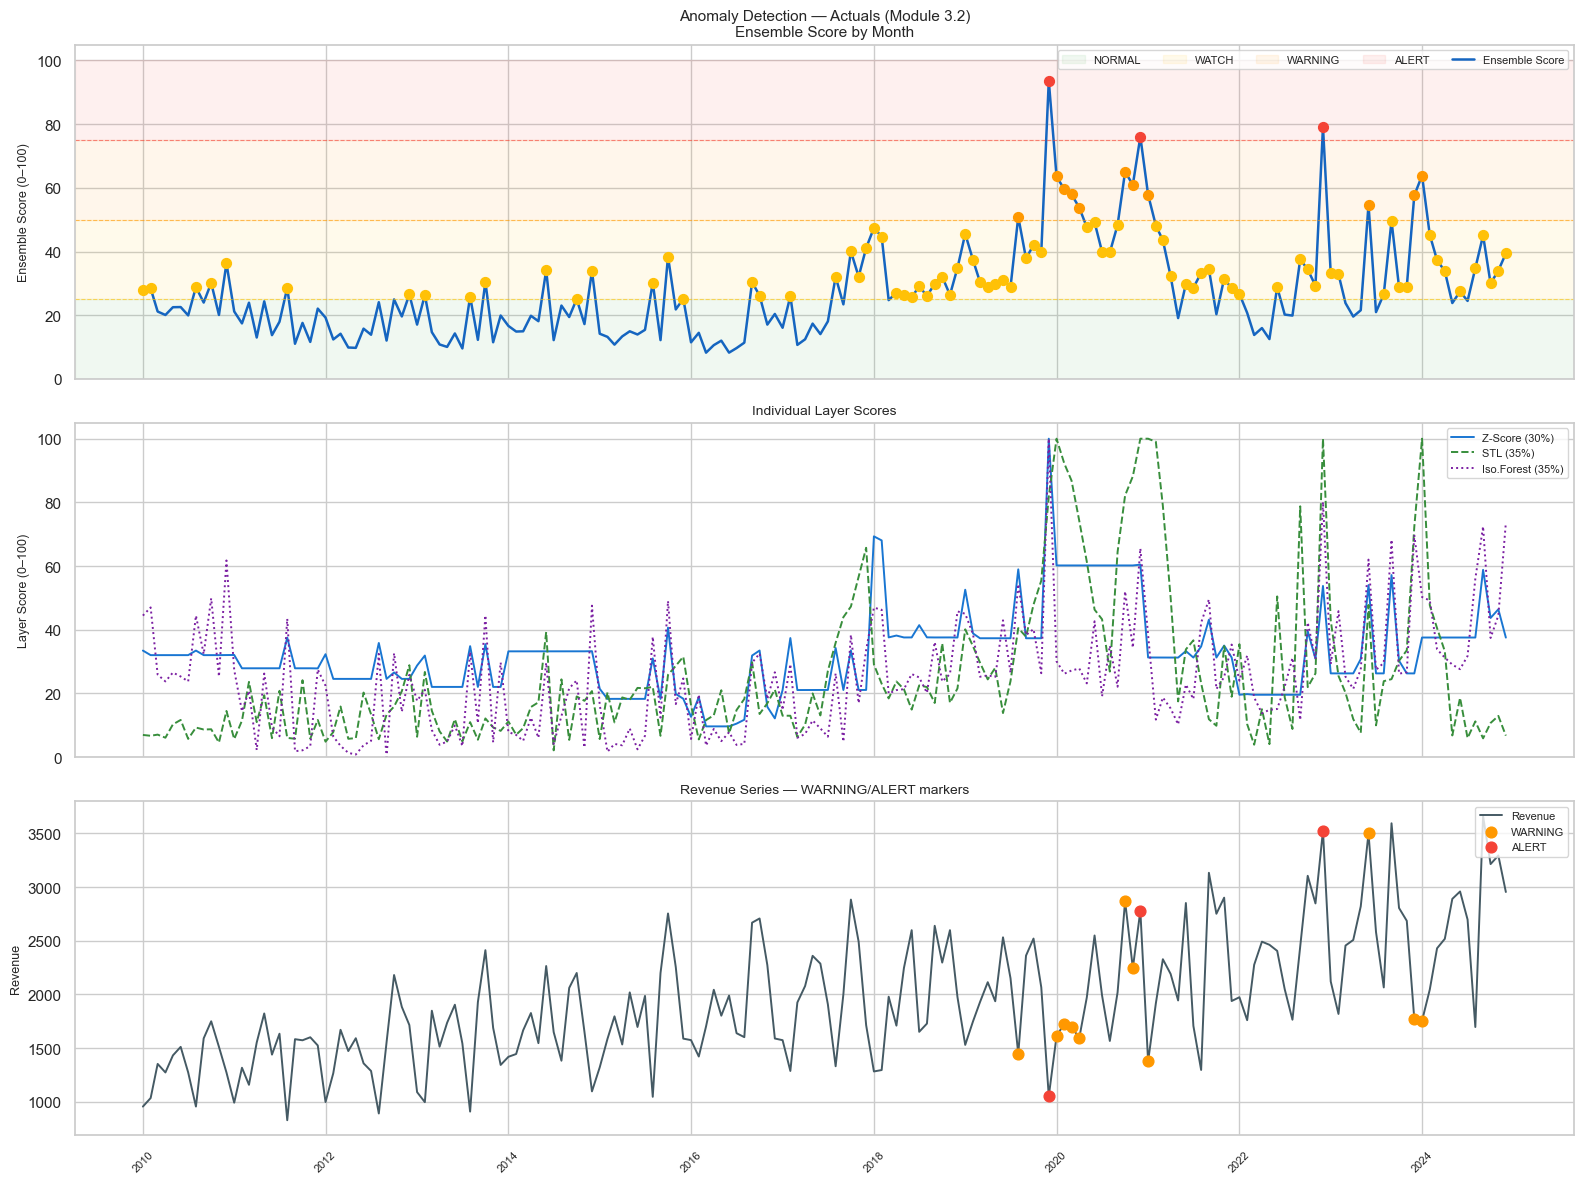

Chart saved: module32_anomaly_actuals_timeline.png


In [12]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

sev_colors = {"NORMAL": "#4CAF50", "WATCH": "#FFC107", "WARNING": "#FF9800", "ALERT": "#F44336"}

# ── Panel 1: Ensemble score with severity shading ─────────────────────────
ax1 = axes[0]
ax1.axhspan(0,  25, alpha=0.08, color="#4CAF50", label="NORMAL")
ax1.axhspan(25, 50, alpha=0.08, color="#FFC107", label="WATCH")
ax1.axhspan(50, 75, alpha=0.08, color="#FF9800", label="WARNING")
ax1.axhspan(75, 100, alpha=0.08, color="#F44336", label="ALERT")
ax1.plot(df_ensemble["date"], df_ensemble["ensemble_score"],
         color="#1565C0", linewidth=1.8, label="Ensemble Score")

for _, row in df_ensemble[df_ensemble["severity"] != "NORMAL"].iterrows():
    ax1.scatter(row["date"], row["ensemble_score"],
                color=sev_colors[row["severity"]], s=50, zorder=5)

ax1.axhline(25, color="#FFC107", linestyle="--", linewidth=0.8, alpha=0.6)
ax1.axhline(50, color="#FF9800", linestyle="--", linewidth=0.8, alpha=0.6)
ax1.axhline(75, color="#F44336", linestyle="--", linewidth=0.8, alpha=0.6)
ax1.set_ylabel("Ensemble Score (0–100)", fontsize=9)
ax1.set_title("Anomaly Detection — Actuals (Module 3.2)\nEnsemble Score by Month", fontsize=11)
ax1.set_ylim(0, 105)
ax1.legend(loc="upper right", fontsize=8, ncol=5)

# ── Panel 2: Individual layer scores ─────────────────────────────────────
ax2 = axes[1]
ax2.plot(df_ensemble["date"], df_ensemble["z_score"],
         label=f"Z-Score ({W_Z:.0%})",   color="#1976D2", linewidth=1.4, linestyle="-")
ax2.plot(df_ensemble["date"], df_ensemble["stl_score"],
         label=f"STL ({W_STL:.0%})",     color="#388E3C", linewidth=1.4, linestyle="--")
ax2.plot(df_ensemble["date"], df_ensemble["iso_score"],
         label=f"Iso.Forest ({W_IF:.0%})",color="#7B1FA2", linewidth=1.4, linestyle=":")
ax2.set_ylabel("Layer Score (0–100)", fontsize=9)
ax2.set_title("Individual Layer Scores", fontsize=10)
ax2.set_ylim(0, 105)
ax2.legend(loc="upper right", fontsize=8)

# ── Panel 3: Revenue time series with ALERT markers ───────────────────────
ax3 = axes[2]
if rev_col and rev_col in df_plm_sorted.columns:
    ax3.plot(df_plm_sorted["date"], df_plm_sorted[rev_col],
             color="#455A64", linewidth=1.4, label="Revenue")
    alerts = df_ensemble[df_ensemble["severity"].isin(["ALERT", "WARNING"])]
    if not alerts.empty:
        alert_rev = pd.merge(alerts[["datekey", "date", "severity"]], df_plm_sorted[["datekey", rev_col]], on="datekey")
        for sev in ["WARNING", "ALERT"]:
            sub = alert_rev[alert_rev["severity"] == sev]
            if not sub.empty:
                ax3.scatter(sub["date"], sub[rev_col],
                            color=sev_colors[sev], s=60, zorder=5, label=sev)
    ax3.set_ylabel("Revenue", fontsize=9)
    ax3.set_title("Revenue Series — WARNING/ALERT markers", fontsize=10)
    ax3.legend(loc="upper right", fontsize=8)
else:
    ax3.text(0.5, 0.5, "Revenue column not found", ha="center", va="center", transform=ax3.transAxes)

for ax in axes:
    ax.tick_params(axis="x", rotation=45, labelsize=8)

plt.tight_layout()
plt.show()
print("Chart saved: module32_anomaly_actuals_timeline.png")

## The 3 anomaly charts

### 1. Ensemble Score by Month

This is the main chart.

It shows the **final anomaly score** for each month after combining the three layers:
- Z-Score
- STL
- Isolation Forest

**This chart answers: When did the company behave outside its normal financial pattern?**

In the project narrative:
- earlier years are mostly stable
- the **2018–2019 stress period** begins to show higher anomaly levels
- **2020 shows the strongest spikes**, indicating a major disruption
- later periods show a **partial recovery**, although some warning signals remain

So this chart is the executive view of anomaly intensity over time.

### 2. Individual Layer Scores

This chart breaks the ensemble into its three components:
- **Z-Score**
- **STL**
- **Isolation Forest**

**This chart answers: Why was a month flagged as anomalous?**

Examples:
- if **STL spikes**, the issue is likely a break in trend or seasonality
- if **Z-Score spikes**, the month is statistically extreme
- if **Isolation Forest spikes**, the anomaly is driven by a combination of several KPIs

In the stress and crisis periods, multiple layers rise together, which confirms that the anomaly is not just noise, but a real business event.

### 3. Revenue Series with Warning / Alert Markers

This chart overlays anomaly severity on top of the **revenue time series**.

**This chart answers: Did the anomaly affect revenue behavior?**

In the project context:
- warnings and alerts appear around the company stress period
- the strongest markers align with crisis-like disruption
- later years show recovery, but still with some monitored fluctuations

This chart is useful because it connects the technical anomaly score to a business variable that executives immediately understand: **revenue**.

## 12. Visualization — Heatmap: Anomaly Score by Month × KPI

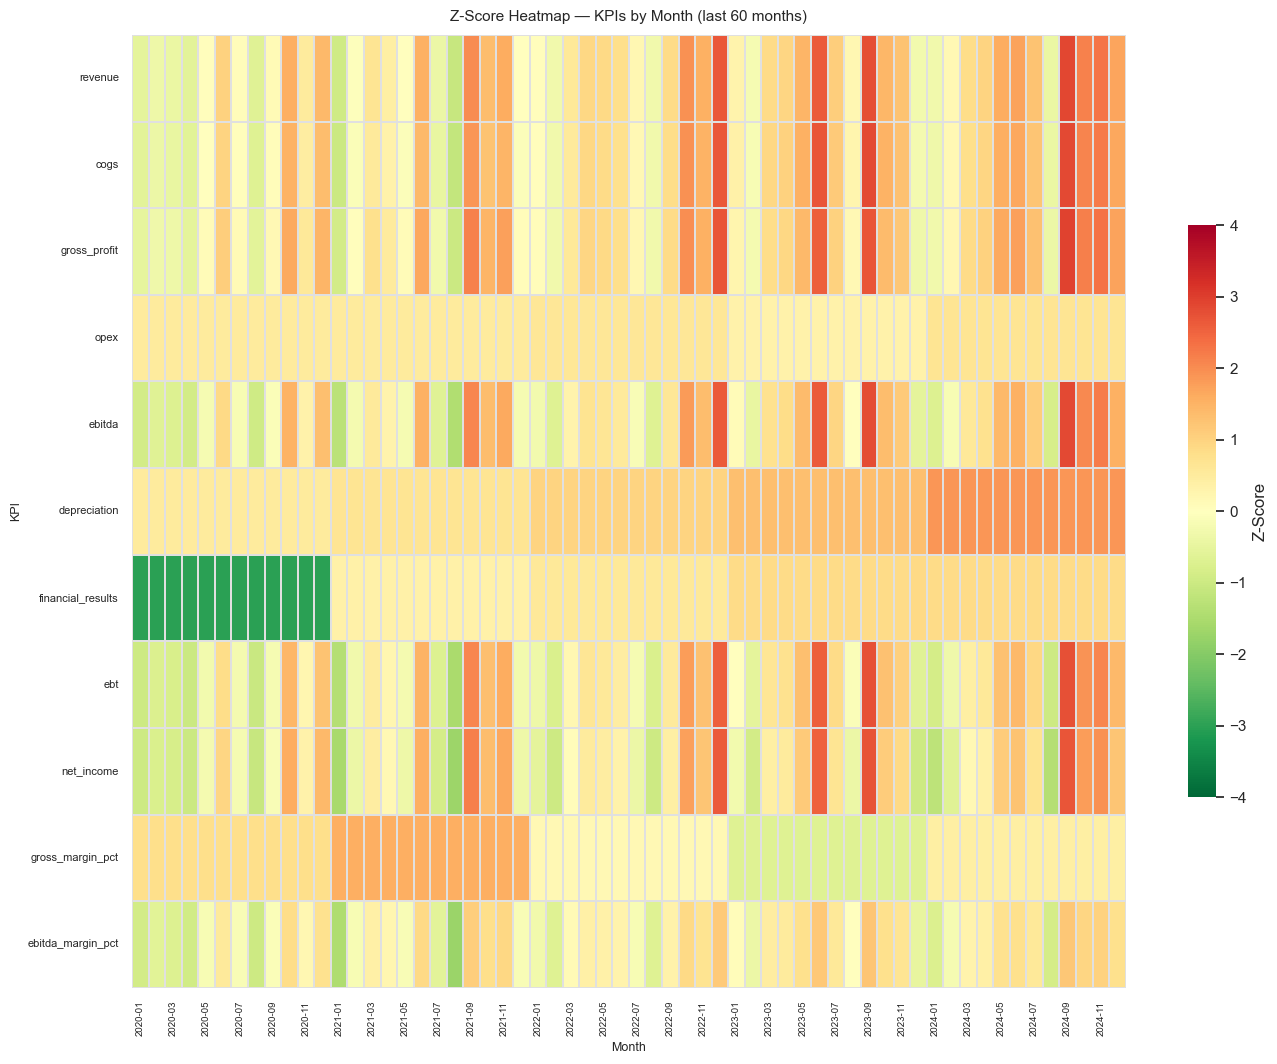

In [13]:
# Build z-score heatmap (months × KPIs)
z_cols = [c for c in df_zscore.columns if c.startswith("z_") and c not in ["z_max_abs", "z_score", "z_kpi_flagged"]]

if z_cols and not df_zscore.empty:
    _hm_idx = "date" if "date" in df_zscore.columns else "datekey"
    heatmap_df = df_zscore.set_index(_hm_idx)[z_cols].copy()
    heatmap_df.columns = [c.replace("z_", "") for c in heatmap_df.columns]
    if _hm_idx == "date":
        heatmap_df.index = heatmap_df.index.strftime("%Y-%m")

    # Limit to last 60 months for readability
    heatmap_df = heatmap_df.tail(60)

    fig_h, ax_h = plt.subplots(figsize=(14, max(8, len(heatmap_df) * 0.18)))
    sns.heatmap(
        heatmap_df.T,
        cmap="RdYlGn_r",
        center=0,
        vmin=-4, vmax=4,
        linewidths=0.3,
        linecolor="#e0e0e0",
        annot=False,
        ax=ax_h,
        cbar_kws={"label": "Z-Score", "shrink": 0.6}
    )
    ax_h.set_title("Z-Score Heatmap — KPIs by Month (last 60 months)", fontsize=11, pad=10)
    ax_h.set_xlabel("Month", fontsize=9)
    ax_h.set_ylabel("KPI", fontsize=9)
    ax_h.tick_params(axis="x", rotation=90, labelsize=7)
    ax_h.tick_params(axis="y", labelsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("No z-score columns available for heatmap.")

## Z-Score Heatmap — How to Read

This heatmap shows how each KPI deviates from its historical average over time.

- **Rows** → KPIs (revenue, EBITDA, net income, etc.)
- **Columns** → time (monthly)
- **Color** → Z-score (standard deviation from the mean)

### Z-Score Interpretation
- `0` → normal (around average)
- `+` values → above average
- `-` values → below average

### Color Guide
- 🟢 Green → significantly below normal
- 🟡 Yellow → normal range
- 🟠 Orange → above normal
- 🔴 Red → extreme high (outlier)

### What do -4 and +4 mean?
- **+4** → extremely high value (rare event)
- **-4** → extremely low value (rare event)

### Is extreme good or bad?
It depends on the KPI:
- Revenue / Profit → high can be good
- Costs → high is usually bad
- Margins → high is good, low is bad

### Key Insight
The model does **not judge good vs bad** — it detects:
> “This is unusual compared to history”

Use this heatmap to identify **which KPIs are driving anomalies**.

## 13. Full Anomaly Report — Export

In [14]:
# ── Merge PLM values into final report ────────────────────────────────────
report_cols_plm = ["datekey"] + plm_if_cols[:6]  # top 6 PLM KPIs for context
df_report = pd.merge(
    df_ensemble,
    df_plm_sorted[report_cols_plm],
    on="datekey",
    how="left"
)

df_report = df_report.sort_values("ensemble_score", ascending=False).reset_index(drop=True)

print("=" * 90)
print("FULL ANOMALY REPORT — TOP 20 MONTHS (sorted by Ensemble Score)")
print("=" * 90)
display_cols = [
    "datekey", "ensemble_score", "severity",
    "z_score", "stl_score", "iso_score",
    "z_kpi_flagged", "stl_kpi_flagged"
]
print(df_report[display_cols].head(20).to_string(index=False))


# ── Final summary ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("LAYER SUMMARY")
print("=" * 60)
print(f"  Layer 1A — Quality Gate       : {(df_quality['status'] == 'PASS').sum()}/{len(df_quality)} PASS")
print(f"  Layer 1B — Cross-Validation   : {(df_cv['status'] == 'PASS').sum()}/{len(df_cv)} PASS")
print(f"  Layer 1C — BS Reconciliation  : {bs_check.get('status', 'N/A')}")
print(f"  Layer 2  — Z-Score anomalies  : {len(flagged_z)} months flagged")
print(f"  Layer 3  — STL anomalies      : {len(flagged_stl)} months flagged")
print(f"  Layer 4  — Isolation Forest   : {len(flagged_if)} months flagged")
print(f"  Ensemble ALERT  months        : {(df_ensemble['severity'] == 'ALERT').sum()}")
print(f"  Ensemble WARNING months       : {(df_ensemble['severity'] == 'WARNING').sum()}")
print(f"  Ensemble WATCH  months        : {(df_ensemble['severity'] == 'WATCH').sum()}")
print(f"  Ensemble NORMAL months        : {(df_ensemble['severity'] == 'NORMAL').sum()}")

FULL ANOMALY REPORT — TOP 20 MONTHS (sorted by Ensemble Score)
 datekey  ensemble_score severity  z_score  stl_score  iso_score     z_kpi_flagged   stl_kpi_flagged
  201912           93.65    ALERT   100.00      81.86     100.00 ebitda_margin_pct               ebt
  202212           79.18    ALERT    53.76     100.00      80.15      gross_profit              cogs
  202012           76.07    ALERT    60.45     100.00      65.54 financial_results financial_results
  202010           65.04  WARNING    60.20      82.17      52.06 financial_results financial_results
  202401           63.87  WARNING    37.57     100.00      50.28      depreciation      depreciation
  202001           63.60  WARNING    60.20     100.00      30.11 financial_results              opex
  202011           60.97  WARNING    60.20      88.19      34.40 financial_results financial_results
  202002           59.51  WARNING    60.20      92.21      26.21 financial_results              opex
  202003           57.98  WA